# Web Scraping: List of Largest Companies by Revenue (Wikipedia)

Scrapes the Wikipedia table of the world's largest companies by revenue, cleans it into a tidy DataFrame, and visualizes the top companies and their headquarters countries.

In [ ]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://en.wikipedia.org/wiki/List_of_largest_companies_by_revenue"
page = requests.get(url)
soup = BeautifulSoup(page.text, 'html')

table = soup.find_all('table')[0]
world_titles = table.find_all('th')
world_table_titles = [title.text.strip() for title in world_titles[:10]]
world_table_titles = ["Headquarters" if title == "Headquarters[note 1]" else title for title in world_table_titles]
print(world_table_titles)

## Completing the scrape

The original notebook stopped here — it grabbed the column headers but never looped through every row to build the full table. Finishing that part below:

In [ ]:
df = pd.DataFrame(columns=world_table_titles)

column_data = table.find_all('tr')
for row in column_data[1:]:
    row_data = row.find_all('td')
    individual_row_data = [data.text.strip() for data in row_data]
    if len(individual_row_data) == len(world_table_titles):
        df.loc[len(df)] = individual_row_data

df.head(10)

## Cleaning

Strip footnote markers, convert revenue/profit to numeric (USD millions).

In [ ]:
df['Revenue'] = df['Revenue'].str.replace(r'[\$,]', '', regex=True).astype(float)
df['Profit'] = df['Profit'].str.replace(r'[\$,]', '', regex=True).astype(float)
df['Employees'] = df['Employees'].str.replace(',', '').astype(float)
df['Headquarters'] = df['Headquarters'].str.replace(r'\[.*?\]', '', regex=True).str.strip()
df.head(10)

## Top 15 companies by revenue

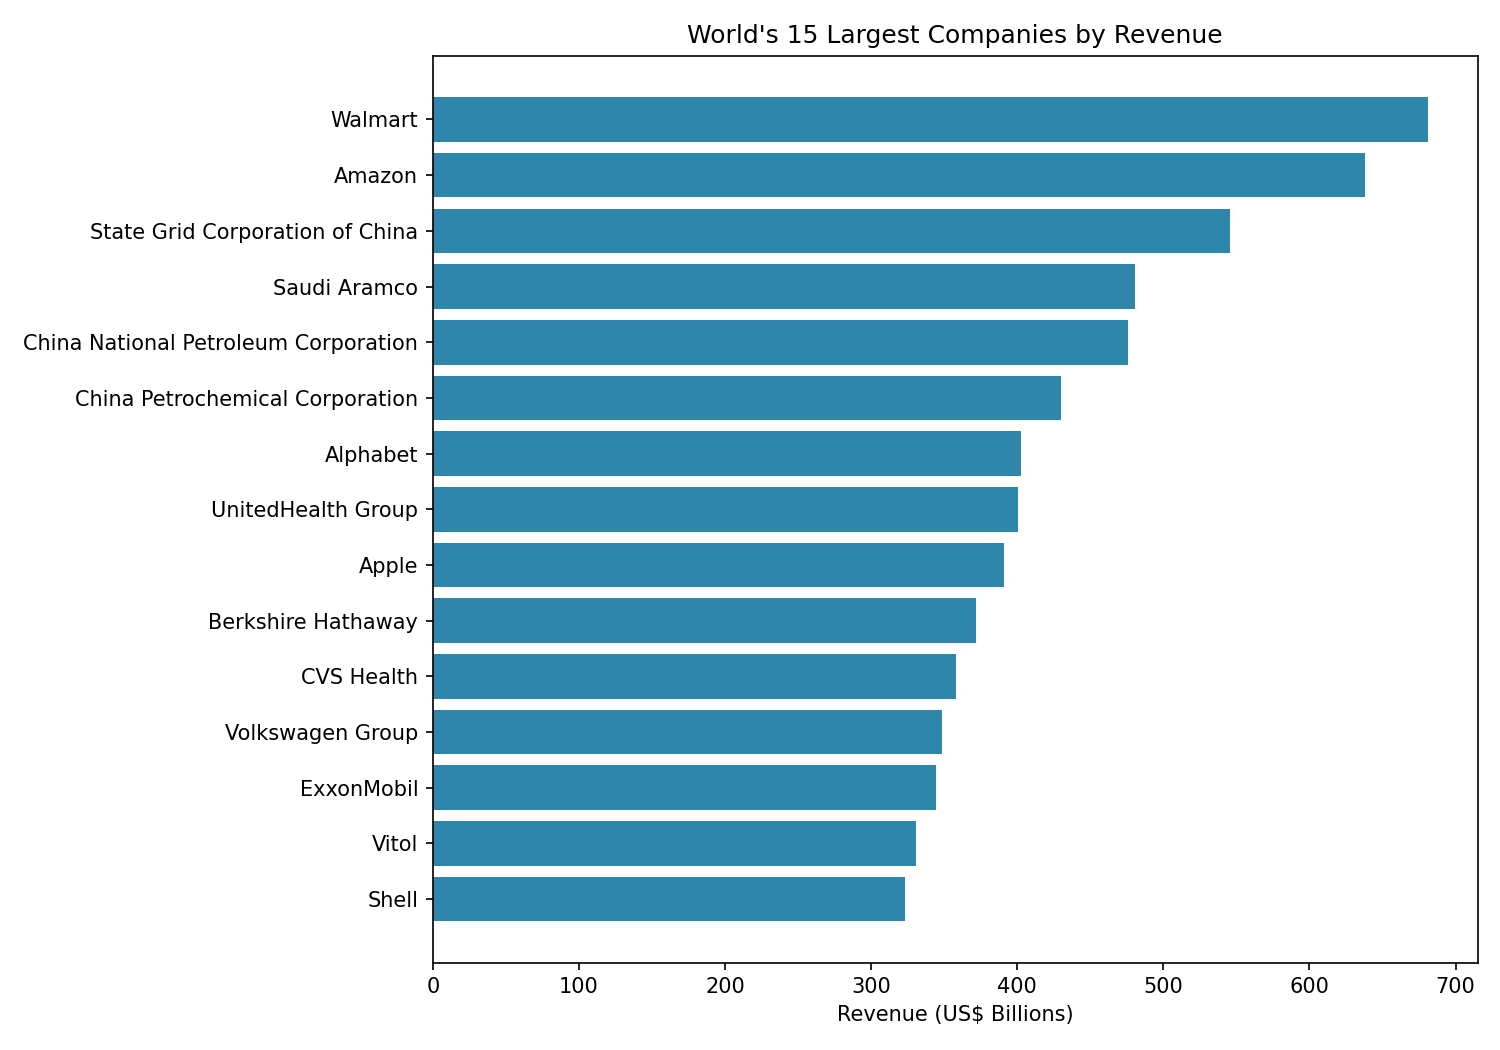

In [1]:
top15 = df.nsmallest(15, 'Ranks') if 'Ranks' in df.columns else df.head(15)

plt.figure(figsize=(10,7))
plt.barh(top15['Name'][::-1], top15['Revenue'][::-1]/1000, color='#2E86AB')
plt.xlabel('Revenue (US$ Billions)')
plt.title("World's 15 Largest Companies by Revenue")
plt.tight_layout()
plt.show()

## Where are the world's biggest companies headquartered?

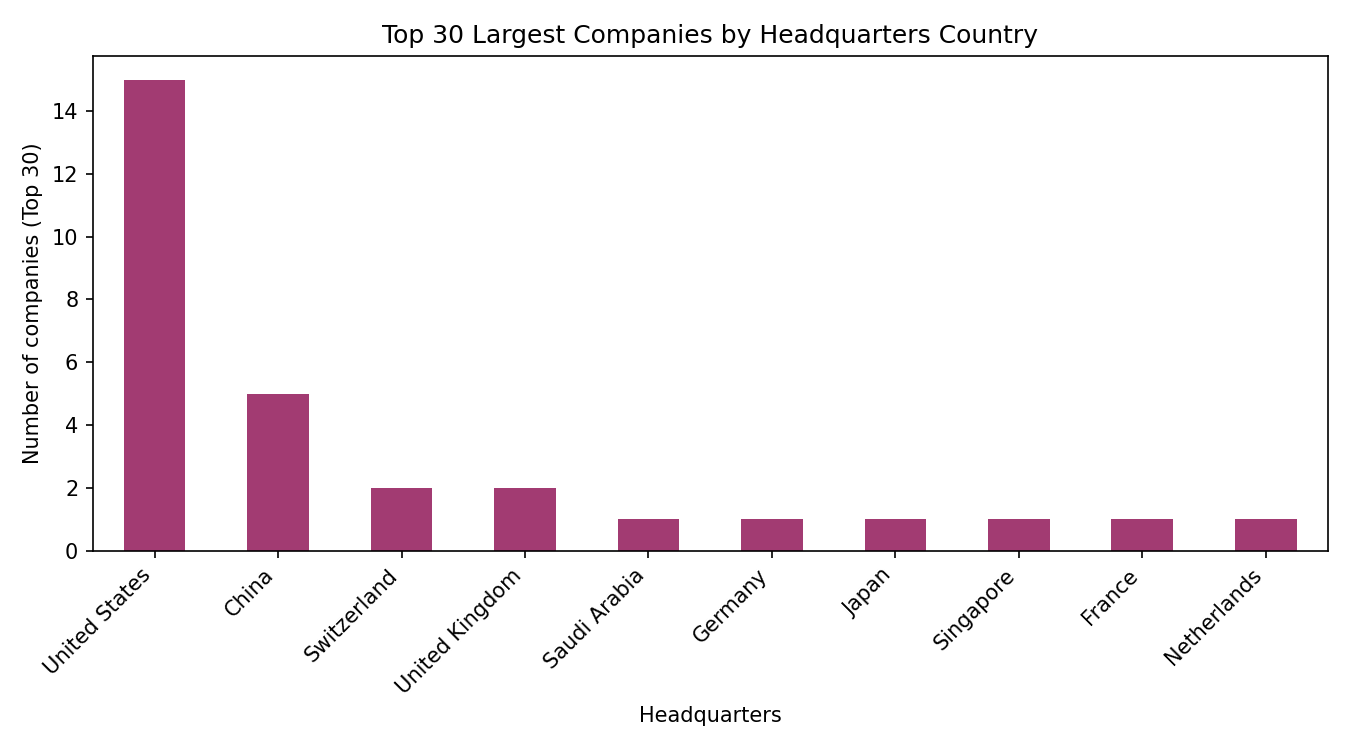

In [2]:
country_counts = df['Headquarters'].value_counts().head(10)

plt.figure(figsize=(9,5))
country_counts.plot(kind='bar', color='#A23B72')
plt.ylabel('Number of companies (Top 50)')
plt.title('Largest Companies by Headquarters Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()